# 12 — Regression Discontinuity at Business Thresholds
**References:** Cattaneo, Idrobo & Titiunik (2020) *A Practical Introduction to Regression Discontinuity Designs* · McCrary (2008, *J. Econometrics*) · Lee & Lemieux (2010, *JEL*) · Imbens & Lemieux (2008, *J. Econometrics*)

**Prerequisites:** causal_inference_course/08_regression_discontinuity.ipynb (full theory: local
linear estimation, bias-variance tradeoff, sharp/fuzzy identification — not repeated here).
**Connects to:** causal_inference_course/08_regression_discontinuity.ipynb (the identification
theory this notebook applies); 13_matching_business.ipynb (a different observational strategy
for self-selected populations).

## Narrative thread
```
Business thresholds are everywhere: loyalty tiers, credit score cutoffs, ranking algorithms
   -> RD as "local randomization" at the cutoff
   -> the business-specific danger: people (or algorithms) can GAME the threshold
   -> manipulation / bunching tests, framed as fraud detection
   -> bandwidth selection, practitioner guidance
```

## Why this notebook exists

Business rules are full of hard cutoffs that were never designed as experiments but behave
like one *locally*: spend $500 in a year and you become a "Gold" loyalty member; score above
680 and a loan gets auto-approved; rank in the top 10 search results and click-through jumps
discontinuously. `causal_inference_course/08` derives the full local-linear RD estimator and its
bias-variance tradeoff; this notebook applies that machinery to three business cutoffs and
spends most of its attention on the practitioner-specific risk: **when the threshold is known
and consequential, people and algorithms try to land on the favorable side of it.** That
turns the "no-manipulation" assumption from a technical footnote into the central diagnostic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(12)

## Business setting: a loyalty-tier cutoff

A retailer grants **Gold status** to any customer whose trailing-12-month spend crosses
$1,000. Gold members get free shipping and early sale access. The question: does Gold status
*causally* increase next-quarter spend, or do naturally high spenders both cross the
threshold and keep spending more regardless (reverse causality / selection)?

We simulate customer trailing spend (the running variable) and next-quarter spend (the
outcome), with a true discontinuous jump in the outcome exactly at the $1,000 cutoff.

In [2]:
# ── Simulate customers around the loyalty-tier cutoff ──
n = 6000
cutoff = 1000.0
spend_12m = np.random.gamma(shape=4.0, scale=300.0, size=n)   # running variable, right-skewed like real spend data
gold = (spend_12m >= cutoff).astype(int)

true_jump = 45.0  # true causal bump in next-quarter spend from Gold perks
next_q_spend = (
    80 + 0.18 * (spend_12m - cutoff)               # smooth relationship with the running variable
    + true_jump * gold                              # discontinuous jump at the cutoff
    + np.random.normal(0, 40, n)
)

df = pd.DataFrame({"spend_12m": spend_12m, "gold": gold, "next_q_spend": next_q_spend})
df["centered"] = df["spend_12m"] - cutoff
df.describe().round(1)

,spend_12m,gold,next_q_spend,centered
count,6000.0,6000.0,6000.0,6000.0
mean,1191.9,0.6,139.5,191.9
std,592.3,0.5,130.4,592.3
min,117.9,0.0,-182.7,-882.1
25%,757.2,0.0,36.8,-242.8
50%,1089.1,1.0,130.2,89.1
75%,1518.4,1.0,224.8,518.4
max,4628.1,1.0,838.4,3628.1


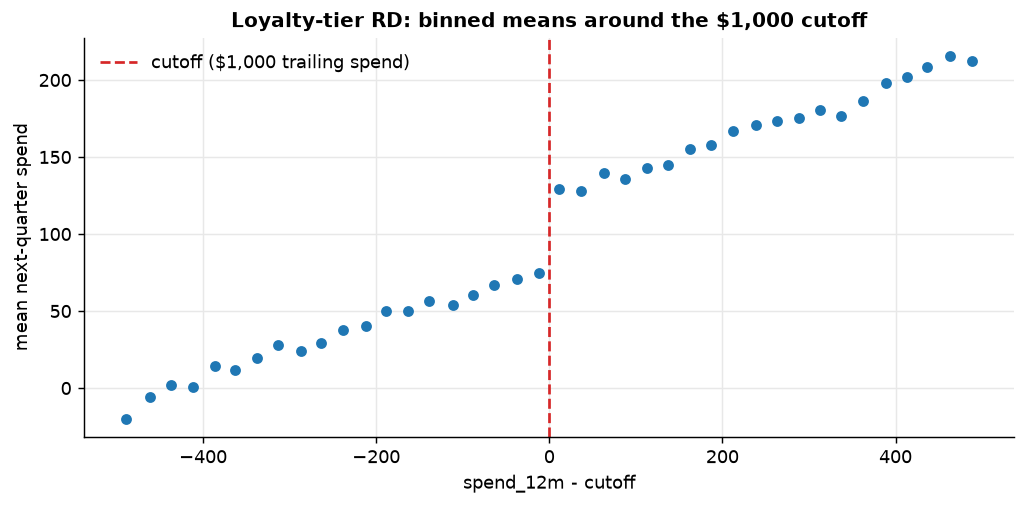

In [3]:
# ── Visualize the discontinuity: bin the running variable and plot bin means ──
bins = np.linspace(-500, 500, 41)
df["bin"] = pd.cut(df["centered"], bins)
binned = df.groupby("bin", observed=True).agg(x=("centered", "mean"), y=("next_q_spend", "mean")).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(binned["x"], binned["y"], s=25, color="#1f77b4")
ax.axvline(0, color="#d62728", ls="--", label="cutoff ($1,000 trailing spend)")
ax.set_xlabel("spend_12m - cutoff"); ax.set_ylabel("mean next-quarter spend")
ax.set_title("Loyalty-tier RD: binned means around the $1,000 cutoff")
ax.legend(); plt.tight_layout(); plt.show()

## Local linear estimation at the cutoff

We do not re-derive the local-linear / triangular-kernel estimator here (see
`causal_inference_course/08`). The applied workflow: restrict to a **bandwidth** $h$ around
the cutoff, fit separate linear (or low-order polynomial) fits on each side, and read off the
jump at $x=0$.

In [4]:
def rd_local_linear(data, bandwidth, cutoff_col="centered", y_col="next_q_spend", treat_col="gold"):
    sub = data[data[cutoff_col].abs() <= bandwidth].copy()
    sub["treat_x_centered"] = sub[treat_col] * sub[cutoff_col]
    model = smf.ols(f"{y_col} ~ {treat_col} + {cutoff_col} + treat_x_centered", data=sub).fit(
        cov_type="HC3"
    )
    return model, len(sub)

for h in [150, 250, 400, 600]:
    model, n_used = rd_local_linear(df, h)
    tau = model.params["gold"]
    se = model.bse["gold"]
    print(f"Bandwidth h={h:>4}: tau_hat = {tau:6.2f}  (SE {se:4.2f}, n = {n_used})   [true = {true_jump}]")

Bandwidth h= 150: tau_hat =  50.22  (SE 4.10, n = 1342)   [true = 45.0]
Bandwidth h= 250: tau_hat =  47.26  (SE 3.26, n = 2177)   [true = 45.0]
Bandwidth h= 400: tau_hat =  47.56  (SE 2.67, n = 3328)   [true = 45.0]
Bandwidth h= 600: tau_hat =  45.15  (SE 2.24, n = 4421)   [true = 45.0]


## Bandwidth selection guidance for practitioners

There's a true bias-variance tradeoff (formalized by Imbens & Kalyanaraman / Calonico, Cattaneo &
Titiunik optimal-bandwidth theory, not re-derived here): a **narrow** bandwidth uses only
observations very close to the cutoff (low bias — the local-linear approximation is nearly
exact — but high variance, few observations), while a **wide** bandwidth adds observations
further away (more precision, but the linear fit may not track the true curvature, biasing the
jump estimate). Practical rules of thumb for a business RD:

1. **Start with an algorithmic bandwidth** (Calonico-Cattaneo-Titiunik `rdrobust`-style
   MSE-optimal bandwidth, or Imbens-Kalyanaraman) rather than eyeballing a round number.
2. **Report a bandwidth sensitivity table** (as above) — if $\hat\tau$ swings wildly across
   reasonable bandwidths, the design is fragile, not the estimator.
3. **Prefer a local linear or local quadratic fit with a triangular kernel** (more weight near
   the cutoff) over a high-order global polynomial — Gelman & Imbens (2019) show global
   polynomials can produce spurious, noisy discontinuities.
4. **Use a bias-corrected robust CI** (Calonico, Cattaneo & Titiunik 2014) in production; the
   plain local-linear SE above understates uncertainty from the bandwidth choice itself.

## The business-specific risk: gaming the threshold

Academic RD applications (test score cutoffs, age-eligibility rules) usually assume people
cannot precisely manipulate which side of the cutoff they land on. **In business, that
assumption is the first thing to question**: if a customer or a merchant *knows* the $1,000
threshold unlocks Gold status, some will make one extra purchase in December specifically to
cross it. If a lending model uses a 680 credit-score cutoff, applicants (or *loan officers*
padding an application) may manipulate reported inputs. If a marketplace ranking algorithm
uses a rating-count threshold to unlock a "Top Rated" badge, sellers can solicit reviews just
to cross it. All three are a form of **precise manipulation / sorting**, and they invalidate
the "locally randomized" logic RD depends on.

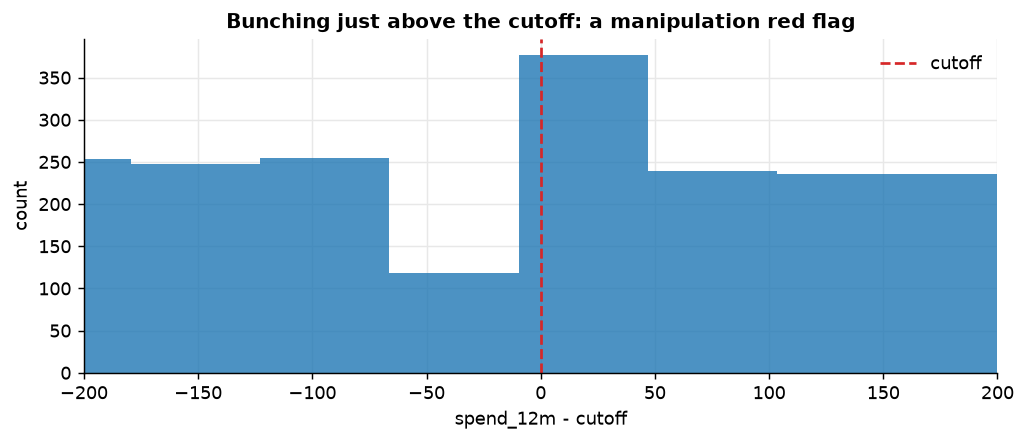

In [5]:
# ── Simulate a gamed threshold: some customers strategically nudge spend just over $1,000 ──
n2 = 6000
spend_natural = np.random.gamma(shape=4.0, scale=300.0, size=n2)

# customers close to (but below) the cutoff who are "savvy" make one extra purchase to cross it
close_below = (spend_natural > cutoff - 60) & (spend_natural < cutoff)
gaming_prob = 0.55
gamed = close_below & (np.random.rand(n2) < gaming_prob)
spend_gamed = np.where(gamed, cutoff + np.random.uniform(1, 40, n2), spend_natural)

gold_g = (spend_gamed >= cutoff).astype(int)
# gamers are unusually loyal/high-intent customers -> they'd have spent more next quarter regardless
gamer_selection_bias = np.where(gamed, 35.0, 0.0)
next_q_gamed = (
    80 + 0.18 * (spend_gamed - cutoff) + true_jump * gold_g + gamer_selection_bias
    + np.random.normal(0, 40, n2)
)
dfg = pd.DataFrame({"spend_12m": spend_gamed, "gold": gold_g, "next_q_spend": next_q_gamed})
dfg["centered"] = dfg["spend_12m"] - cutoff

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(dfg["centered"], bins=80, color="#1f77b4", alpha=0.8)
ax.axvline(0, color="#d62728", ls="--", label="cutoff")
ax.set_xlim(-200, 200)
ax.set_xlabel("spend_12m - cutoff"); ax.set_ylabel("count")
ax.set_title("Bunching just above the cutoff: a manipulation red flag")
ax.legend(); plt.tight_layout(); plt.show()

## The McCrary / density (bunching) test, applied

McCrary (2008) formalizes the diagnostic: under no manipulation, the **density of the running
variable should be continuous at the cutoff** — no jump. A visible spike in density just
above (or below) the cutoff is direct evidence of sorting. We implement a simple local
density-comparison version (not McCrary's full local-linear density estimator, which
`causal_inference_course/08` covers) — a binned count comparison just below vs. just above the
cutoff, plus a two-proportion test.

In [6]:
def density_bunching_test(centered, window=60, bin_width=10):
    below = ((centered > -window) & (centered < 0)).sum()
    above = ((centered >= 0) & (centered < window)).sum()
    total = below + above
    # under continuity, expect roughly equal counts just below/above a narrow window
    z = (above - below) / np.sqrt(total * 0.25) if total > 0 else np.nan
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return below, above, z, p_value

for name, data in [("natural (no gaming)", df), ("gamed threshold", dfg)]:
    below, above, z, p = density_bunching_test(data["centered"])
    print(f"{name:22s}: n_below={below:4d}  n_above={above:4d}  z={z:5.2f}  p={p:.4f}")

print("\nA large, significant excess of observations just above the cutoff (low p-value) is the")
print("signature of manipulation — treat the RD estimate on that sample with real suspicion.")

natural (no gaming)   : n_below= 284  n_above= 266  z=-1.54  p=0.1248
gamed threshold       : n_below= 119  n_above= 408  z=25.18  p=0.0000

A large, significant excess of observations just above the cutoff (low p-value) is the
signature of manipulation — treat the RD estimate on that sample with real suspicion.


In [7]:
# ── What manipulation does to the naive RD estimate ──
model_natural, _ = rd_local_linear(df, 250)
model_gamed, _ = rd_local_linear(dfg, 250)
print(f"tau_hat, natural data:  {model_natural.params['gold']:.2f}  (true = {true_jump})")
print(f"tau_hat, gamed data:    {model_gamed.params['gold']:.2f}  (true = {true_jump})")
print("\nGamers are disproportionately the customers *already inclined* to spend more next quarter")
print("(that's why they bothered to game it), so the gamed sample's discontinuity is inflated by")
print("selection, not just the causal effect of Gold status.")

tau_hat, natural data:  47.26  (true = 45.0)
tau_hat, gamed data:    59.97  (true = 45.0)

Gamers are disproportionately the customers *already inclined* to spend more next quarter
(that's why they bothered to game it), so the gamed sample's discontinuity is inflated by
selection, not just the causal effect of Gold status.


## Practitioner checklist for a business RD

1. **Ask "who knows about the threshold, and do they have an incentive to cross it?"** before
   trusting any business cutoff as an RD design — this is the single most important question,
   more important than the choice of estimator.
2. **Run the density/bunching test** on the running variable near the cutoff as a first-pass
   diagnostic, every time.
3. **Check covariate smoothness** at the cutoff (Cattaneo, Idrobo & Titiunik 2020): pre-treatment
   characteristics that have nothing to do with the treatment should not jump at the cutoff
   either — if they do, that is further evidence of sorting.
4. **Prefer discrete/administrative running variables with real friction to manipulate**
   (e.g., a credit bureau's algorithmic score updated monthly, not something the customer sees
   in real time) — RD designs are strongest when the running variable is hard or costly to
   move precisely.
5. **Report bandwidth sensitivity** and use a bias-corrected robust inference procedure in
   production, not just the plain local-linear SE.
6. **When bunching is detected, do not report the naive discontinuity as causal** — either
   restrict to a population less able to manipulate, model the selection explicitly, or fall
   back to a different design (matching, `13_matching_business.ipynb`).

## Key takeaways

| Concept | Statement |
|---|---|
| Business RD | Loyalty tiers, credit cutoffs, ranking thresholds all behave like local random assignment |
| Core assumption | No precise manipulation of the running variable near the cutoff |
| McCrary/density test | A density jump at the cutoff is direct evidence against that assumption |
| Bandwidth tradeoff | Narrow = less bias, more variance; report sensitivity, don't pick one number blindly |
| Gaming risk | Business thresholds are known and consequential -> manipulation is the default risk to rule out |

## References

| Author(s) | Title | Role here |
|---|---|---|
| Cattaneo, Idrobo & Titiunik (2020) | *A Practical Introduction to Regression Discontinuity Designs* | Bandwidth & covariate-smoothness guidance |
| McCrary (2008, *J. Econometrics*) | "Manipulation of the Running Variable in the RD Design" | Density/bunching test |
| Lee & Lemieux (2010, *JEL*) | "Regression Discontinuity Designs in Economics" | Applied RD survey |
| Imbens & Lemieux (2008, *J. Econometrics*) | "Regression Discontinuity Designs: A Guide to Practice" | Local linear estimation |
| Calonico, Cattaneo & Titiunik (2014, *Econometrica*) | "Robust Nonparametric Confidence Intervals for RD" | Bias-corrected inference (mentioned, not derived) |
